# Language Detection Using Recurrent Neural Networks

**Nizar Elouarti | AI 574 | Assignment 1**

Given a sentence, predict one of the ten Tatoeba language codes. This is multiclass sentence classification. Unlike a word-based sentiment model, this detector reads **characters**: spelling, accents, and character order provide useful language cues, including for unfamiliar words.

We use a character embedding followed by a bidirectional GRU (a gated recurrent neural network) and a linear classifier. The two final recurrent states summarize the sentence; cross-entropy trains the classifier on raw logits.

## Data and Experimental Design

The supplied training file actually has **100,000** sentences (10,000 per language); the development file has **10,000** (1,000 per language). To match the requested experiment, we select a seeded, stratified **10,000-sentence training subset**, and retain the complete development file for validation. Exact normalized train/validation duplicates are excluded from the training pool. Set `TRAIN_SIZE = None` to use the entire eligible training pool.

Character vocabulary and class mappings are fitted on training data only. Validation selects the best epoch; it is **not an independent test set**. Results below are measured by running the notebook, not assumed.

Device: cpu; original training rows: 100,000
Train/validation overlap rows removed: 0
Training: 10,000; validation: 10,000; vocabulary: 125


,train,validation
language,,
ber,1000,1000
deu,1000,1000
eng,1000,1000
epo,1000,1000
fra,1000,1000
hun,1000,1000
ita,1000,1000
por,1000,1000
spa,1000,1000


,minimum,median,mean,maximum,p95,truncated_percent
language,,,,,,
ber,5,29.0,31.17,135,56.00,0.0
deu,6,39.0,46.48,320,98.00,1.0
eng,9,34.0,38.48,228,72.05,0.4
epo,3,35.0,40.78,328,87.05,0.7
fra,7,36.0,41.73,398,80.00,0.5
hun,6,30.0,33.71,214,65.00,0.1
ita,5,30.0,32.85,172,61.00,0.2
por,5,33.0,37.64,804,71.00,0.3
spa,6,33.0,38.21,388,74.00,0.4


,language,text
0,ber,maɣef ur thimt ara deg temlilit?
1,deu,kumi spielt im moment tennis.
2,eng,his jacket was as threadbare and worn-out as i...
3,epo,"se vi volas paroli, ni parolu."
4,fra,quel âge aurais-tu si tu ne savais pas quel âg...
5,hun,"egyél, amíg meleg."
6,ita,perché mi chiedi di insegnartelo?
7,por,todos nós somos responsáveis perante a lei.
8,spa,¿quieres salir fuera a jugar?
9,tur,onları nerede duydunuz?


,max_length,training_retained_percent
0,80,96.50
1,120,98.91
2,160,99.63
3,240,99.89


Sentences truncated: train 0.37%; validation 0.52%
train: repeated (language, text) rows = 0; texts with multiple language labels = 0
validation: repeated (language, text) rows = 0; texts with multiple language labels = 0
Unknown characters in truncated validation inputs: 0.0027%


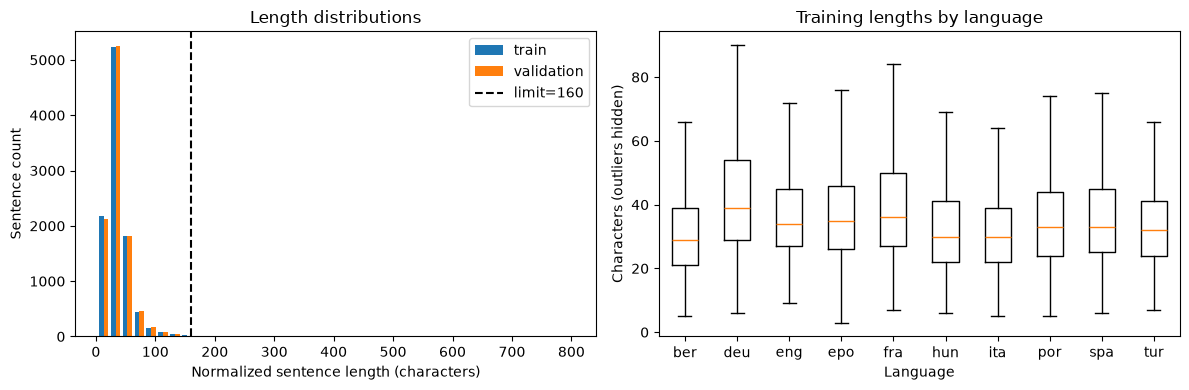

In [1]:
from pathlib import Path
import random
import unicodedata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, f1_score
from torch import nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_sequence
from torch.utils.data import DataLoader

SEED = 42
TRAIN_SIZE = 10_000
MAX_LENGTH = 160
BATCH_SIZE = 128
EPOCHS = 10
LEARNING_RATE = 0.003

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.set_num_threads(min(4, torch.get_num_threads()))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

candidate_roots = [Path.cwd(), *Path.cwd().parents]
assignment_dir = next(
    (candidate for root in candidate_roots
     for candidate in (root, root / 'AI 574' / 'Assignment_1')
     if (candidate / 'Data' / 'tatoeba' / 'sentences.top10langs.train.tsv').is_file()),
    None,
 )
if assignment_dir is None:
    raise FileNotFoundError('Run from the repository or assignment directory containing Data/tatoeba.')
data_dir = assignment_dir / 'Data' / 'tatoeba'


def normalize_text(text):
    return unicodedata.normalize('NFC', text).strip().lower()


def load_sentences(path):
    frame = pd.read_csv(path, sep='\t', header=None, names=['language', 'text'],
                        quoting=3, keep_default_na=False, encoding='utf-8')
    if frame.empty or not frame['language'].str.fullmatch(r'[a-z]{3}').all():
        raise ValueError(f'Invalid language codes in {path.name}')
    frame['text'] = frame['text'].map(normalize_text)
    if frame['text'].eq('').any():
        raise ValueError(f'Empty sentences in {path.name}')
    return frame


train_pool = load_sentences(data_dir / 'sentences.top10langs.train.tsv')
val_frame = load_sentences(data_dir / 'sentences.top10langs.dev.tsv')
original_train_count = len(train_pool)
train_pool = train_pool.loc[~train_pool['text'].isin(set(val_frame['text']))].copy()
removed_overlap = original_train_count - len(train_pool)
languages = sorted(train_pool['language'].unique())
assert len(languages) == 10
assert set(val_frame['language']) == set(languages)
if TRAIN_SIZE is None:
    train_frame = train_pool.reset_index(drop=True)
else:
    if TRAIN_SIZE <= 0 or TRAIN_SIZE % len(languages):
        raise ValueError('TRAIN_SIZE must be positive and divisible by the number of languages.')
    per_language = TRAIN_SIZE // len(languages)
    train_frame = pd.concat([
        train_pool.loc[train_pool['language'].eq(language)].sample(per_language, random_state=SEED)
        for language in languages
    ], ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True)

language_names = {
    'ber': 'Berber', 'deu': 'German', 'eng': 'English', 'epo': 'Esperanto',
    'fra': 'French', 'hun': 'Hungarian', 'ita': 'Italian', 'por': 'Portuguese',
    'spa': 'Spanish', 'tur': 'Turkish',
}
label_to_id = {language: index for index, language in enumerate(languages)}
PAD_ID, UNK_ID = 0, 1
characters = sorted(set(''.join(train_frame['text'])))
char_to_id = {'<PAD>': PAD_ID, '<UNK>': UNK_ID}
char_to_id.update({character: index + 2 for index, character in enumerate(characters)})

print(f'Device: {device}; original training rows: {original_train_count:,}')
print(f'Train/validation overlap rows removed: {removed_overlap:,}')
print(f'Training: {len(train_frame):,}; validation: {len(val_frame):,}; vocabulary: {len(char_to_id)}')
display(pd.DataFrame({'train': train_frame.language.value_counts(),
                      'validation': val_frame.language.value_counts()}).sort_index())

training_lengths = train_frame.text.str.len()
validation_lengths = val_frame.text.str.len()
length_summary = train_frame.assign(characters=training_lengths).groupby('language').characters.agg(
    minimum='min', median='median', mean='mean', maximum='max')
length_summary['p95'] = training_lengths.groupby(train_frame.language).quantile(0.95)
length_summary['truncated_percent'] = 100 * training_lengths.gt(MAX_LENGTH).groupby(train_frame.language).mean()
display(length_summary.round(2))
display(train_frame.sort_values('language').groupby('language', sort=True).head(1).reset_index(drop=True))
display(pd.DataFrame({'max_length': [80, 120, 160, 240],
                      'training_retained_percent': [100 * training_lengths.le(limit).mean() for limit in [80, 120, 160, 240]]}))
print(f'Sentences truncated: train {training_lengths.gt(MAX_LENGTH).mean():.2%}; validation {validation_lengths.gt(MAX_LENGTH).mean():.2%}')
for split, frame in [('train', train_frame), ('validation', val_frame)]:
    print(f'{split}: repeated (language, text) rows = {frame.duplicated(["language", "text"]).sum()}; '
          f'texts with multiple language labels = {frame.groupby("text").language.nunique().gt(1).sum()}')
validation_characters = ''.join(val_frame.text.str.slice(0, MAX_LENGTH))
unknown_rate = sum(character not in char_to_id for character in validation_characters) / len(validation_characters)
print(f'Unknown characters in truncated validation inputs: {unknown_rate:.4%}')

figure, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist([training_lengths, validation_lengths], bins=40, label=['train', 'validation'])
axes[0].axvline(MAX_LENGTH, color='black', linestyle='--', label=f'limit={MAX_LENGTH}')
axes[0].set(xlabel='Normalized sentence length (characters)', ylabel='Sentence count', title='Length distributions')
axes[0].legend()
axes[1].boxplot([training_lengths[train_frame.language.eq(code)] for code in languages],
                tick_labels=languages, showfliers=False)
axes[1].set(xlabel='Language', ylabel='Characters (outliers hidden)', title='Training lengths by language')
figure.tight_layout()
plt.show()
assert length_summary.index.tolist() == languages and training_lengths.gt(0).all()
assert not set(train_frame.text).intersection(val_frame.text)

## Exploration Findings and Preprocessing

The selected training and validation splits each contain 1,000 sentences per language. German training sentences have the highest median length (39 characters), whereas Berber has a median of 29. Lengths are right-skewed: the longest training sentence has 804 characters, while each language's 95th percentile is below 100. A fixed length should therefore handle typical inputs without making every batch as long as the rare outliers.

A limit of **160 characters retains 99.63% of training sentences intact**, versus 96.50% at 80 and 98.91% at 120. It truncates 0.37% of training and 0.52% of validation sentences. This is a practical compute/information trade-off, not a proven optimal length. There are no repeated normalized (language, text) rows or texts with conflicting labels within either selected split, and exact normalized train/validation overlap is absent. These checks do not exclude near-duplicates or related translations. Only 0.0027% of characters in truncated validation inputs are unknown to the training vocabulary.

## Character Encoding and Recurrent Classifier

Normalize Unicode to NFC and lowercase while preserving accents, spaces, and punctuation. The displayed language samples contain distinctive accented letters and punctuation, which character inputs retain without requiring a multilingual word tokenizer. Each character becomes a training-vocabulary ID; unseen characters use `<UNK>`. Sentences are truncated to 160 characters, padded within each batch, and **packed using their actual lengths** so padding never enters the recurrent state.

| Choice | Rationale |
|---|---|
| Character embedding, 32 dimensions | Compact learned representations of the 125-symbol vocabulary; preserves unfamiliar word spellings. |
| Bidirectional GRU, 64 hidden units per direction | Reads character order in both directions for whole-sentence classification; smaller gated architecture than an equivalently sized LSTM. Not suitable for causal streaming. |
| Final forward/backward states | Produces one fixed-size representation per sentence without treating padding as content. |
| Dropout 0.2 and gradient clipping 1.0 | Moderate regularization and a bound on gradient norm during recurrent training. |
| Adam, learning rate 0.003, batch size 128 | Practical starting settings for this small model and dataset, not outcomes of an exhaustive search. |
| Lowest validation loss, patience 3, at most 10 epochs | Selects a checkpoint by probabilistic loss rather than the final epoch and limits overtraining. |
| Training-only UNK replacement, probability 0.1 | Trains the embedding used for unknown characters and explanation masks without perturbing validation inputs. |

The network is `Embedding(32) -> bidirectional GRU(64) -> Dropout(0.2) -> Linear(10)`. It produces one score per language. Cross-entropy consumes raw logits; softmax is used only for inference and explanation probabilities. A character n-gram TF-IDF + linear SVM baseline below tests whether learned recurrent context improves on simpler local spelling features. Its comparison is not an ablation of masking, and these hyperparameters are not claimed to be optimal.

In [2]:
def encode_text(text, vocabulary=None, max_length=MAX_LENGTH):
    if not isinstance(text, str) or not isinstance(max_length, int) or isinstance(max_length, bool) or max_length <= 0:
        raise ValueError('Provide a string and a positive integer max_length.')
    text = normalize_text(text)
    if not text:
        raise ValueError('Provide a non-empty sentence.')
    vocabulary = char_to_id if vocabulary is None else vocabulary
    return torch.tensor([vocabulary.get(character, UNK_ID) for character in text[:max_length]],
                        dtype=torch.long)


def expect_value_error(function, *args, **kwargs):
    try:
        function(*args, **kwargs)
    except ValueError:
        return
    raise AssertionError(f'{function.__name__} must reject invalid input.')


def make_dataset(frame):
    return [(encode_text(text), label_to_id[language])
            for language, text in frame.itertuples(index=False, name=None)]


def collate_sentences(batch):
    sequences, targets = zip(*batch)
    lengths = torch.tensor([len(sequence) for sequence in sequences], dtype=torch.long)
    return (pad_sequence(sequences, batch_first=True, padding_value=PAD_ID),
            lengths, torch.tensor(targets, dtype=torch.long))


train_dataset, val_dataset = make_dataset(train_frame), make_dataset(val_frame)
shuffle_generator = torch.Generator().manual_seed(SEED)
loader_options = dict(batch_size=BATCH_SIZE, collate_fn=collate_sentences, num_workers=0)
train_loader = DataLoader(train_dataset, shuffle=True, generator=shuffle_generator, **loader_options)
val_loader = DataLoader(val_dataset, shuffle=False, **loader_options)


class LanguageRNN(nn.Module):
    def __init__(self, vocab_size, num_classes, embedding_dim=32, hidden_size=64, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=PAD_ID)
        self.rnn = nn.GRU(embedding_dim, hidden_size, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, character_ids, lengths):
        packed = pack_padded_sequence(self.embedding(character_ids), lengths.cpu(),
                                      batch_first=True, enforce_sorted=False)
        _, hidden = self.rnn(packed)
        return self.classifier(self.dropout(torch.cat((hidden[-2], hidden[-1]), dim=1)))


model_config = dict(vocab_size=len(char_to_id), num_classes=len(languages),
                    embedding_dim=32, hidden_size=64, dropout=0.2)
criterion = nn.CrossEntropyLoss()
assert len(train_dataset) == len(train_frame) and len(val_dataset) == len(val_frame)
assert torch.equal(train_dataset[0][0], encode_text(train_frame.iloc[0]['text']))
expect_value_error(encode_text, 'Hello', max_length=0)
expect_value_error(encode_text, 'Hello', max_length=-1)
expect_value_error(encode_text, 123)
print(f'Encoded {len(train_dataset):,} training and {len(val_dataset):,} validation sentences; input guards passed.')

Encoded 10,000 training and 10,000 validation sentences; input guards passed.


## Training and Model Selection

`run_epoch` handles training and evaluation, optionally collecting predictions for the classification report. Evaluation uses inference mode; loss and accuracy totals remain on the model device until the end of the epoch. Adam, cross-entropy, gradient clipping at 1.0, patience of three non-improving epochs, and lowest-validation-loss selection are used.

Training independently replaces each non-padding character with `<UNK>` with probability **0.1**. Validation and prediction are never randomly masked; padding is never replaced. Set `mask_probability=0` to disable this augmentation. Training on some masked characters does not make an entirely masked sentence a neutral baseline or guarantee faithful explanations.

The next cell defines `train_model`; the following one runs the final experiment on all 10,000 selected training examples. **Every call starts fresh**: model weights, optimizer, Torch seed, and the shuffle generator are reset together. It does not continue from the older unmasked checkpoint. Subsequent evaluation, prediction, and interpretation outputs describe this newly trained model. The diagnostic cell also runs two separate 32-example CPU smoke tests, which do not replace the final model and are not performance experiments.

In [3]:
import time


def mask_training_characters(character_ids, probability):
    if not 0 <= probability <= 1:
        raise ValueError('Character masking probability must be between 0 and 1.')
    if probability == 0:
        return character_ids
    selected = (torch.rand(character_ids.shape, device=character_ids.device) < probability)
    return character_ids.masked_fill(selected & character_ids.ne(PAD_ID), UNK_ID)


def run_epoch(network, loader, optimizer=None, collect=False):
    training = optimizer is not None
    network.train(training)
    actual, predicted, total_examples = [], [], 0
    network_device = next(network.parameters()).device
    totals = torch.zeros(2, dtype=torch.float64, device=network_device)
    with (torch.enable_grad() if training else torch.inference_mode()):
        for character_ids, lengths, targets in loader:
            character_ids, targets = character_ids.to(network_device), targets.to(network_device)
            if training:
                optimizer.zero_grad(set_to_none=True)
                character_ids = mask_training_characters(
                    character_ids, getattr(network, 'character_mask_probability', 0.0),
                )
            logits = network(character_ids, lengths)
            loss = criterion(logits, targets)
            if not torch.isfinite(loss):
                raise RuntimeError('Non-finite training or validation loss.')
            if training:
                loss.backward()
                nn.utils.clip_grad_norm_(network.parameters(), max_norm=1.0)
                optimizer.step()
            guesses = logits.argmax(dim=1)
            total_examples += targets.size(0)
            totals[0].add_(loss.detach().double(), alpha=targets.size(0))
            totals[1].add_((guesses == targets).sum())
            if collect:
                actual.extend(targets.cpu().tolist())
                predicted.extend(guesses.cpu().tolist())
    if not total_examples:
        raise ValueError('The data loader must contain examples.')
    loss, accuracy = (totals / total_examples).tolist()
    return loss, accuracy, actual, predicted


def train_model(epochs=EPOCHS, patience=3, train_batches=None, val_batches=None,
                mask_probability=0.1, training_device=None):
    if epochs < 1 or patience < 1 or not 0 <= mask_probability <= 1:
        raise ValueError('Use positive epochs/patience and a masking probability in [0, 1].')
    torch.manual_seed(SEED)
    shuffle_generator.manual_seed(SEED)
    network = LanguageRNN(**model_config).to(device if training_device is None else training_device)
    network.character_mask_probability = mask_probability
    optimizer = torch.optim.Adam(network.parameters(), lr=LEARNING_RATE)
    train_batches = train_loader if train_batches is None else train_batches
    val_batches = val_loader if val_batches is None else val_batches
    history, best_state, best_epoch, stale_epochs = [], None, 0, 0
    best_loss = float('inf')
    for epoch in range(1, epochs + 1):
        start = time.perf_counter()
        train_loss, train_accuracy, _, _ = run_epoch(network, train_batches, optimizer)
        val_loss, val_accuracy, _, _ = run_epoch(network, val_batches)
        history.append(dict(epoch=epoch, train_loss=train_loss, val_loss=val_loss,
                            train_accuracy=train_accuracy, val_accuracy=val_accuracy))
        print(f'Epoch {epoch:02d}: train {train_loss:.4f}/{train_accuracy:.2%} | '
              f'validation {val_loss:.4f}/{val_accuracy:.2%} | {time.perf_counter() - start:.1f}s', flush=True)
        if val_loss < best_loss:
            best_loss, best_epoch, stale_epochs = val_loss, epoch, 0
            best_state = {name: value.detach().cpu().clone() for name, value in network.state_dict().items()}
        else:
            stale_epochs += 1
            if stale_epochs >= patience:
                print('Early stopping: validation loss stopped improving.')
                break
    network.load_state_dict(best_state)
    network.eval()
    print(f'Restored best model from epoch {best_epoch}.')
    return network, pd.DataFrame(history), best_epoch, best_loss


mask_probe = torch.tensor([[2, 3, PAD_ID]])
assert torch.equal(mask_training_characters(mask_probe, 0), mask_probe)
assert mask_training_characters(mask_probe, 1).tolist() == [[UNK_ID, UNK_ID, PAD_ID]]
print('Training-mask checks passed: probability endpoints and unchanged padding.')

Training-mask checks passed: probability endpoints and unchanged padding.


In [4]:
model, history_frame, best_epoch, best_val_loss = train_model()

Epoch 01: train 1.5214/47.81% | validation 0.7815/72.05% | 26.8s
Epoch 02: train 0.7085/75.24% | validation 0.4630/82.94% | 27.4s
Epoch 03: train 0.4510/84.17% | validation 0.2962/89.67% | 27.1s
Epoch 04: train 0.3153/88.79% | validation 0.2349/91.65% | 29.3s
Epoch 05: train 0.2339/91.99% | validation 0.1739/94.12% | 27.0s
Epoch 06: train 0.2007/93.29% | validation 0.1403/95.38% | 26.3s
Epoch 07: train 0.1732/94.36% | validation 0.1692/94.25% | 27.2s
Epoch 08: train 0.1576/94.93% | validation 0.1469/94.85% | 27.7s
Epoch 09: train 0.1406/95.34% | validation 0.1147/96.09% | 25.8s
Epoch 10: train 0.1186/96.22% | validation 0.1129/96.34% | 26.0s
Restored best model from epoch 10.


## Validation, Baselines, and Error Analysis

The final masked GRU was freshly trained for ten epochs and selected **epoch 10** by lowest validation loss. It achieves **96.34% validation accuracy**, **0.9634 macro F1**, and **0.1129 cross-entropy loss** on all 10,000 validation sentences. These numbers describe the model used by all subsequent predictions and explanations, not the older unmasked checkpoint.

| Model | Validation Accuracy | Macro F1 |
|---|---|---|
| Majority-class baseline | 10.00% | 0.0182 |
| Character 2-4-gram TF-IDF + linear SVM | 99.26% | 0.9926 |
| Masked bidirectional GRU | 96.34% | 0.9634 |

Both learned models use the same normalized training/validation splits and 160-character limit. TF-IDF vocabulary and IDF statistics are fitted on training inputs only; its 20,000-feature cap and minimum document frequency of two limit rare features. The balanced majority baseline predicts one fixed training class. The n-gram classifier outperforms the GRU by **2.92 percentage points**: a recurrent architecture is not automatically better for this task. Local character combinations already contain strong language cues, and a sparse linear classifier can use them effectively with this dataset. That is a plausible explanation, not proof that recurrence is inherently inferior or that these are optimal settings.

Training and validation loss generally fall across the run, with temporary validation-loss increases at epochs 7 and 8. The best checkpoint is also the final epoch; early stopping was not triggered. Training accuracy is measured with dropout and masking, whereas validation uses neither, so validation accuracy exceeding training accuracy is not by itself evidence of leakage.

Portuguese recall is **91.2%** and Spanish recall **92.5%**, the two lowest recalls. The confusion matrix shows Portuguese predictions drifting toward Spanish and Italian. Sentences of at most 20 characters have **90.23%** accuracy (1,341 examples), versus **98.14%** for 40-80 characters (2,803 examples). This association is consistent with short inputs having fewer language cues, but class mix and sentence difficulty can also differ between length bands.

These are **validation**, not independent test results. The same development split selects the GRU checkpoint and supports this comparison, so unseen-test performance and statistical superiority have not been established. A future experiment could reserve a separate test set and compare multiple seeds and controlled masking ablations. The original unmasked checkpoint is preserved separately; it is not a fair masking ablation because its training history differs. Saving remains an explicit action and refuses overwrite by default.

Best epoch: 10; validation loss: 0.1129
Validation accuracy: 96.34%; macro F1: 0.9634
                  precision    recall  f1-score   support

    ber (Berber)      0.990     0.977     0.983      1000
    deu (German)      0.980     0.978     0.979      1000
   eng (English)      0.981     0.962     0.971      1000
 epo (Esperanto)      0.941     0.990     0.965      1000
    fra (French)      0.984     0.959     0.971      1000
 hun (Hungarian)      0.975     0.990     0.983      1000
   ita (Italian)      0.931     0.963     0.947      1000
por (Portuguese)      0.948     0.912     0.930      1000
   spa (Spanish)      0.920     0.925     0.923      1000
   tur (Turkish)      0.987     0.978     0.982      1000

        accuracy                          0.963     10000
       macro avg      0.964     0.963     0.963     10000
    weighted avg      0.964     0.963     0.963     10000



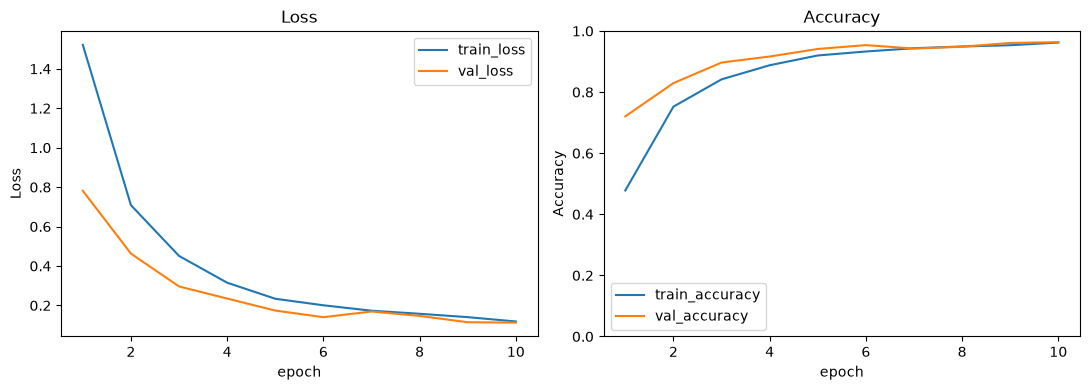

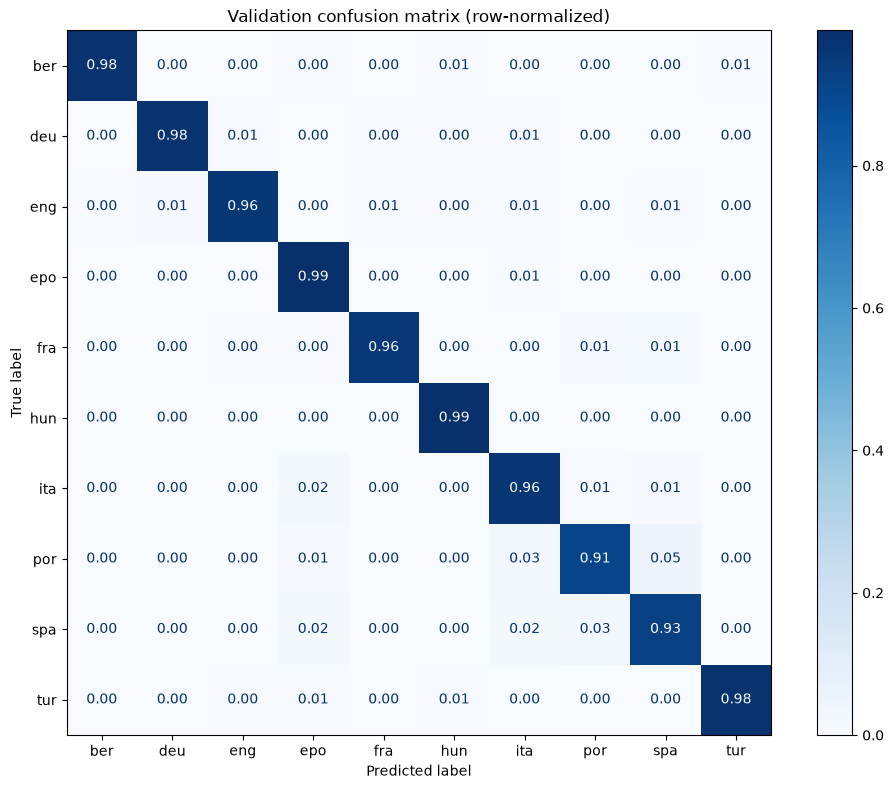

,language,text,predicted
2,por,tu deverias realmente beber menos café.,epo
13,por,abra as malas.,epo
17,por,esta sopa está salgada.,spa
31,por,dirijo muito rápido.,spa
39,por,estás preparado para o pior?,spa
42,por,tom chegou lá na hora certa.,spa
44,por,"sim, claro que concordo.",spa
52,por,adorei estudar coreano.,ita
55,por,esta cadeira de madeira custa sessenta libras.,spa
68,por,adoro cerejas!,spa


,sentences,accuracy
length_band,,
"(0.0, 20.0]",1341,0.902312
"(20.0, 40.0]",5461,0.967588
"(40.0, 80.0]",2803,0.981448
"(80.0, inf]",395,0.984810


,model,validation_accuracy,macro_f1
0,Majority-class baseline,10.00%,0.0182
1,Character n-gram + LinearSVC,99.26%,0.9926
2,Masked bidirectional GRU,96.34%,0.9634


N-gram baseline fit + validation prediction: 3.23s; training-only vocabulary, same splits and 160-character limit.


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.svm import LinearSVC

validation_loss, validation_accuracy, validation_targets, validation_predictions = run_epoch(
    model, val_loader, collect=True,
 )
validation_macro_f1 = f1_score(validation_targets, validation_predictions, average='macro')
assert np.isclose(validation_loss, best_val_loss, atol=1e-6)
assert model.character_mask_probability == 0.1
print(f'Best epoch: {best_epoch}; validation loss: {validation_loss:.4f}')
print(f'Validation accuracy: {validation_accuracy:.2%}; macro F1: {validation_macro_f1:.4f}')
print(classification_report(
    validation_targets, validation_predictions, labels=list(range(len(languages))),
    target_names=[f'{code} ({language_names.get(code, code)})' for code in languages],
    digits=3, zero_division=0,
))

figure, axes = plt.subplots(1, 2, figsize=(11, 4))
for axis, metric in zip(axes, ['loss', 'accuracy']):
    history_frame.plot(x='epoch', y=[f'train_{metric}', f'val_{metric}'], ax=axis)
    axis.set(title=metric.title(), ylabel=metric.title())
axes[1].set_ylim(0, 1)
figure.tight_layout()
plt.show()

ConfusionMatrixDisplay.from_predictions(
    validation_targets, validation_predictions, labels=list(range(len(languages))),
    display_labels=languages, normalize='true', cmap='Blues', values_format='.2f',
    ax=plt.subplots(figsize=(10, 8))[1],
 )
plt.title('Validation confusion matrix (row-normalized)')
plt.tight_layout()
plt.show()

predicted_codes = np.array(languages)[validation_predictions]
errors = val_frame.assign(predicted=predicted_codes).loc[val_frame.language != predicted_codes]
display(errors.head(10))
error_by_length = val_frame.assign(
    length_band=pd.cut(validation_lengths, bins=[0, 20, 40, 80, float('inf')]),
    correct=predicted_codes == val_frame.language.to_numpy(),
).groupby('length_band', observed=True).correct.agg(sentences='size', accuracy='mean')
display(error_by_length)

baseline = make_pipeline(
    TfidfVectorizer(analyzer='char', ngram_range=(2, 4), min_df=2, max_features=20_000, lowercase=False),
    LinearSVC(random_state=SEED),
 )
baseline_start = time.perf_counter()
baseline.fit(train_frame.text.str.slice(0, MAX_LENGTH), train_frame.language.map(label_to_id))
baseline_predictions = baseline.predict(val_frame.text.str.slice(0, MAX_LENGTH))
baseline_seconds = time.perf_counter() - baseline_start
majority_id = label_to_id[train_frame.language.value_counts().idxmax()]
majority_predictions = np.full(len(val_frame), majority_id)
model_comparison = pd.DataFrame([
    dict(model=name, validation_accuracy=float(np.mean(predictions == np.array(validation_targets))),
         macro_f1=f1_score(validation_targets, predictions, average='macro', zero_division=0))
    for name, predictions in [
        ('Majority-class baseline', majority_predictions),
        ('Character n-gram + LinearSVC', baseline_predictions),
        ('Masked bidirectional GRU', np.array(validation_predictions)),
    ]
 ])
display(model_comparison.style.format({'validation_accuracy': '{:.2%}', 'macro_f1': '{:.4f}'}))
print(f'N-gram baseline fit + validation prediction: {baseline_seconds:.2f}s; training-only vocabulary, same splits and 160-character limit.')
assert np.isclose(model_comparison.iloc[-1].validation_accuracy, validation_accuracy)

## Prediction and Explicit Checkpoint Saving

`predict_language` returns ranked language probabilities through the shared batched inference path. Input lengths must be positive integers, and language codes must be unique with one code per classifier output.

Prediction cells **do not save or overwrite checkpoints**. After full training and validation, explicitly run `save_language_model(assignment_dir / 'language_rnn_masked.pt')` to save the selected weights, architecture, vocabulary, language order, normalization, maximum length, masking probability, history, and validation metrics. Saving refuses to overwrite an existing path unless `overwrite=True` is explicitly passed.

Reload with `loaded_model, checkpoint = load_language_model(assignment_dir / 'language_rnn_masked.pt')`, then call `predict_language('Hello world!', predictor=loaded_model)`. Saved preprocessing and language ordering are attached to the loaded model; no manual metadata arguments are needed. Legacy checkpoints without masking metadata default to probability zero. The diagnostic cell uses a temporary file to verify round-trip probabilities, rankings, and overwrite protection without modifying the original checkpoint.

In [6]:
def batch_probabilities(character_ids, lengths, predictor=None):
    predictor = model if predictor is None else predictor
    predictor.eval()
    with torch.inference_mode():
        logits = predictor(character_ids.to(next(predictor.parameters()).device), lengths)
        return logits.softmax(dim=1).cpu().numpy()


def predict_proba(texts, predictor=None, vocabulary=None, max_length=None):
    predictor = model if predictor is None else predictor
    vocabulary = getattr(predictor, 'vocabulary', char_to_id) if vocabulary is None else vocabulary
    max_length = getattr(predictor, 'max_length', MAX_LENGTH) if max_length is None else max_length
    if not isinstance(max_length, int) or isinstance(max_length, bool) or max_length <= 0:
        raise ValueError('max_length must be a positive integer.')
    if len(vocabulary) != predictor.embedding.num_embeddings:
        raise ValueError('Vocabulary size must match the model embedding.')
    texts = [texts] if isinstance(texts, str) else list(texts)
    if not texts:
        return np.empty((0, predictor.classifier.out_features), dtype=np.float32)
    probabilities = []
    for start in range(0, len(texts), BATCH_SIZE):
        batch = [(encode_text(text, vocabulary, max_length), 0) for text in texts[start:start + BATCH_SIZE]]
        character_ids, lengths, _ = collate_sentences(batch)
        probabilities.append(batch_probabilities(character_ids, lengths, predictor))
    return np.concatenate(probabilities)


def predict_language(text, top_k=3, predictor=None, vocabulary=None,
                     language_codes=None, max_length=None):
    predictor = model if predictor is None else predictor
    codes = getattr(predictor, 'language_codes', languages) if language_codes is None else language_codes
    if isinstance(codes, str) or len(codes) != predictor.classifier.out_features or len(set(codes)) != len(codes):
        raise ValueError('Provide one unique language code per model output.')
    if not isinstance(top_k, int) or isinstance(top_k, bool) or not 1 <= top_k <= len(codes):
        raise ValueError('top_k must be between 1 and the number of supported languages.')
    probabilities = predict_proba(text, predictor, vocabulary, max_length)[0]
    indices = np.argsort(-probabilities)[:top_k]
    return pd.DataFrame({'code': [codes[index] for index in indices],
                         'language': [language_names.get(codes[index], codes[index]) for index in indices],
                         'probability': probabilities[indices]})


def save_language_model(path, overwrite=False):
    payload = dict(
        model_state_dict={name: value.detach().cpu() for name, value in model.state_dict().items()},
        model_config=model_config, char_to_id=char_to_id, languages=languages, max_length=MAX_LENGTH,
        normalization='NFC, strip, lowercase', seed=SEED, train_size=len(train_frame),
        best_epoch=best_epoch, best_val_loss=float(best_val_loss), history=history_frame.to_dict('records'),
        character_mask_probability=getattr(model, 'character_mask_probability', 0.0),
        validation_accuracy=float(validation_accuracy), validation_macro_f1=float(validation_macro_f1),
    )
    with Path(path).open('wb' if overwrite else 'xb') as stream:
        torch.save(payload, stream)
    print(f'Saved checkpoint: {path}')


def load_language_model(path):
    payload = torch.load(path, map_location='cpu', weights_only=True)
    predictor = LanguageRNN(**payload['model_config'])
    predictor.load_state_dict(payload['model_state_dict'])
    predictor.character_mask_probability = payload.get('character_mask_probability', 0.0)
    predictor.vocabulary, predictor.language_codes = payload['char_to_id'], payload['languages']
    predictor.max_length = payload['max_length']
    predictor.eval()
    return predictor, payload


example_sentences = {
    'eng': 'This morning I went to the library to read a book.',
    'fra': 'Bonjour, je voudrais un billet pour Paris.',
    'deu': 'Ich lese jeden Morgen die Zeitung.',
    'spa': 'Buenos dias, quiero comprar un libro.',
}
for expected_code, sentence in example_sentences.items():
    print(f'Input ({expected_code}): {sentence}')
    display(predict_language(sentence))
expect_value_error(predict_proba, 'Hello', max_length=0)
expect_value_error(predict_language, 'Hello', language_codes=['eng'], top_k=1)
expect_value_error(predict_language, 'Hello', language_codes=['eng'] * len(languages))
print('Inference guards passed. Prediction does not write or overwrite checkpoints.')

Input (eng): This morning I went to the library to read a book.


,code,language,probability
0,eng,English,0.999956
1,deu,German,0.000035
2,hun,Hungarian,0.000006


Input (fra): Bonjour, je voudrais un billet pour Paris.


,code,language,probability
0,fra,French,0.998456
1,eng,English,0.000873
2,deu,German,0.000548


Input (deu): Ich lese jeden Morgen die Zeitung.


,code,language,probability
0,deu,German,0.999959
1,fra,French,0.000025
2,eng,English,0.000009


Input (spa): Buenos dias, quiero comprar un libro.


,code,language,probability
0,spa,Spanish,0.989314
1,epo,Esperanto,0.004306
2,ita,Italian,0.003329


Inference guards passed. Prediction does not write or overwrite checkpoints.


## Interpreting the Trained RNN with SHAP and LIME

SHAP (SHapley Additive exPlanations) and LIME (Local Interpretable Model-agnostic Explanations) explain predictions by perturbing **character positions**, matching the RNN's input. Repeated letters have separate features, as do spaces and punctuation. The explainers share `predict_proba` with ordinary predictions, using identical normalization, encoding, batching, and softmax without changing model weights.

SHAP and LIME are declared in the repository's `requirements.txt`. Install dependencies once in the chosen Python/kernel environment before running the notebook, rather than reinstalling them during every run. From the repository root, use `python -m pip install -r requirements.txt`. LIME caches the same seeded perturbation probabilities across target classes while still computing each class's own surrogate and fidelity measures.

In [7]:
import shap
from lime.lime_text import LimeTextExplainer

MASK_CHARACTER = chr(0xFFFD)
assert MASK_CHARACTER not in char_to_id


def make_mask_predictor(text):
    sequence = encode_text(text, vocabulary=getattr(model, 'vocabulary', char_to_id),
                           max_length=getattr(model, 'max_length', MAX_LENGTH))

    def probabilities(masks):
        masks = np.atleast_2d(np.asarray(masks))
        if masks.ndim != 2 or masks.shape[1] != len(sequence) or np.any((masks != 0) & (masks != 1)):
            raise ValueError('Use a binary mask matrix with one column per encoded character.')
        if not len(masks):
            return np.empty((0, len(languages)), dtype=np.float32)
        character_ids = torch.where(torch.as_tensor(masks, dtype=torch.bool), sequence.unsqueeze(0), UNK_ID)
        lengths = torch.full((len(masks),), len(sequence), dtype=torch.long)
        return np.concatenate([batch_probabilities(character_ids[start:start + BATCH_SIZE],
                                                   lengths[start:start + BATCH_SIZE])
                               for start in range(0, len(masks), BATCH_SIZE)])

    return probabilities


mask_text = normalize_text('Bonjour, comment allez-vous ?')[:MAX_LENGTH]
mask_predictor = make_mask_predictor(mask_text)
probe_masks = np.vstack([np.ones(len(mask_text)), np.zeros(len(mask_text)),
                         np.random.RandomState(SEED).randint(0, 2, (8, len(mask_text)))])
reference_texts = [''.join(character if keep else MASK_CHARACTER for character, keep in zip(mask_text, mask))
                   for mask in probe_masks]
assert np.allclose(mask_predictor(probe_masks), predict_proba(reference_texts), atol=1e-6)
expect_value_error(mask_predictor, np.zeros((1, len(mask_text) + 1)))
expect_value_error(mask_predictor, np.full((1, len(mask_text)), 0.5))
print(f'SHAP {shap.__version__}; vectorized token masks match text masks, including fully masked input.')

C:\Users\nizare\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP 0.52.0; vectorized token masks match text masks, including fully masked input.


### How to Read the Explanations

**SHAP:** Kernel SHAP estimates contributions from 512 sampled character-mask coalitions. The background is one same-length sentence made entirely of unknown-character tokens, **not the average validation sentence**. An included feature keeps its character; an excluded feature replaces it with an out-of-vocabulary placeholder mapped to `<UNK>`. This preserves sequence length and position. For each class, the masked baseline plus all character contributions reconstructs the original probability; the code checks this numerically. Positive contributions support the target class relative to this baseline, and negative contributions oppose it. Waterfall plots show the largest contributions and group the remainder.

**LIME:** Character-level `LimeTextExplainer`, with `bow=False`, masks individual positions using the same placeholder. It fits a distance-weighted linear surrogate to 2,000 perturbed predictions. Its coefficients approximate how retaining each position changes the target probability within the sampled neighborhood. Positive bars support the class; negative bars oppose it. The report shows weighted R-squared, fitted value at the original sentence, and absolute error relative to the RNN. The surrogate is unconstrained, so its fitted value can fall outside [0, 1]; that is not an invalid RNN probability.

The example explains French and then the first validation error, showing both the predicted class and the true class when they differ. To explain another sentence, call `explain_language_text('Ich lese jeden Morgen die Zeitung.', true_language='deu')`. The optional `true_language` is used only to choose an additional class to explain, not fed to the model. Increase `shap_samples` and `lime_samples` to investigate sampling stability. Positions refer to normalized, truncated model input, not the original raw text.

Text: bonjour, je voudrais un billet pour paris.
Predicted: fra (99.85%); actual: fra

fra: positive contributions support this class; negative oppose it.


,position,character,SHAP,LIME
35,36,,0.110037,0.026124
32,33,o,0.100615,0.057615
29,30,t,0.083798,0.116326
30,31,,0.083542,0.126330
5,6,u,0.080337,0.131426
2,3,n,0.079430,0.086190
40,41,s,0.076785,0.032880
24,25,b,-0.073904,-0.012126
19,20,s,0.069277,0.059045
14,15,u,0.058913,0.061621


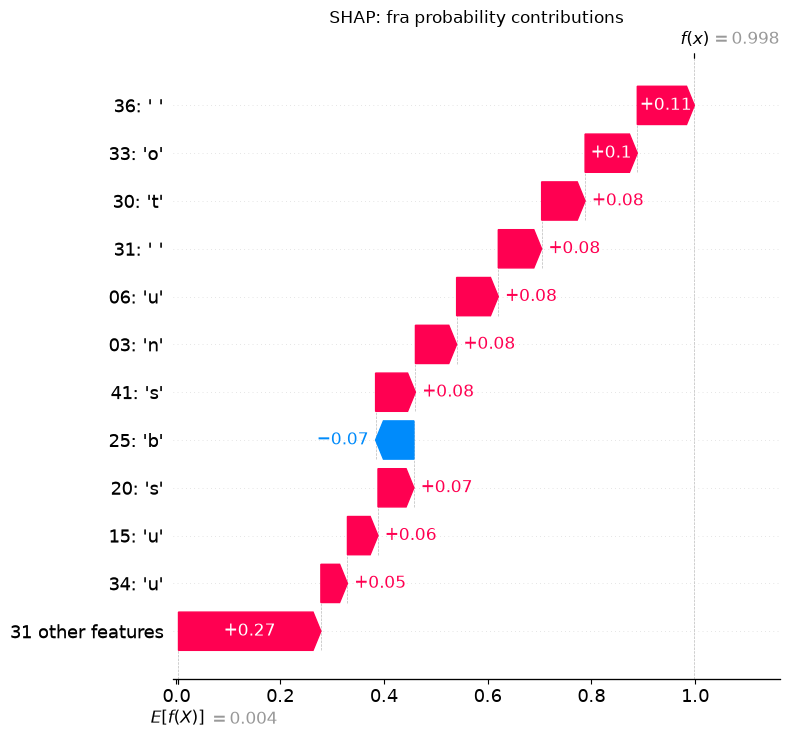

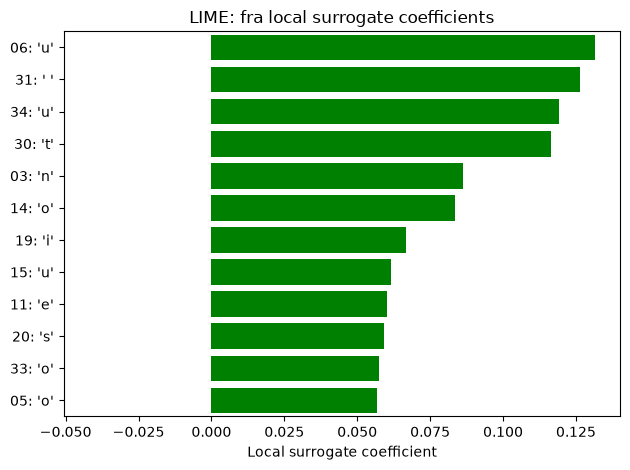

,language,model_probability,SHAP_baseline,SHAP_reconstructed,LIME_local_prediction,LIME_absolute_error,LIME_weighted_R2
0,fra,0.998456,0.003925,0.998456,1.177459,0.179003,0.629077


LIME inference batches: 1 for 1 explained classes.
Text: tu deverias realmente beber menos café.
Predicted: epo (41.06%); actual: por

epo: positive contributions support this class; negative oppose it.


,position,character,SHAP,LIME
37,38,é,-0.321282,-0.329939
2,3,,0.214939,0.181472
10,11,s,0.142278,0.133479
36,37,f,0.127465,0.122392
3,4,d,-0.113979,-0.092291
25,26,e,0.105417,0.106841
24,25,b,0.090017,0.103922
22,23,b,0.080533,0.077950
19,20,t,0.078139,0.062487
15,16,l,0.075389,0.075719


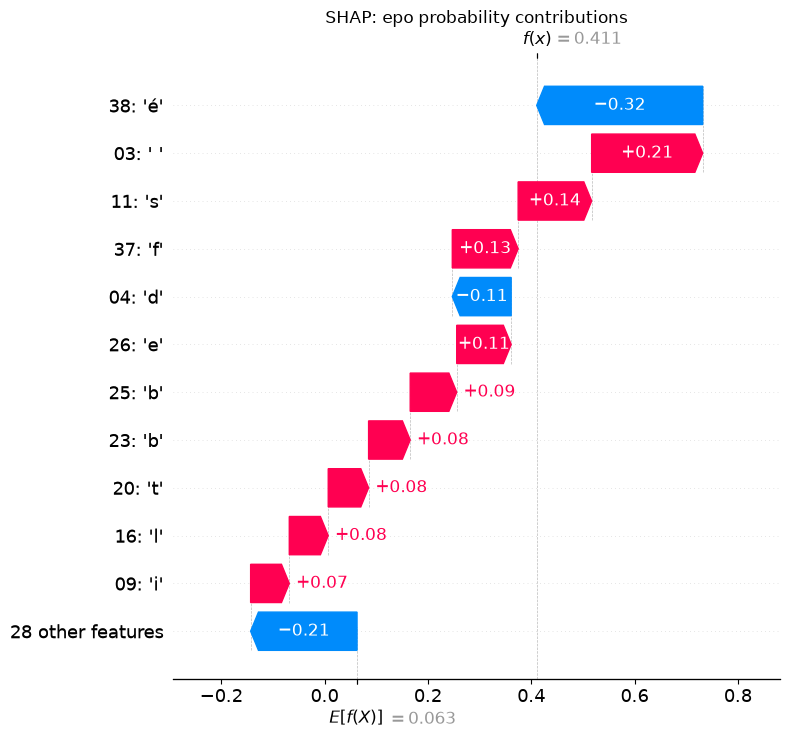

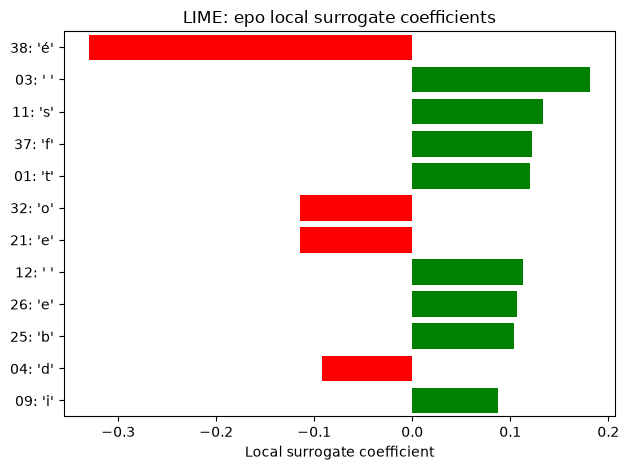


por: positive contributions support this class; negative oppose it.


,position,character,SHAP,LIME
0,1,t,-0.156903,-0.241745
31,32,o,0.088464,0.117602
15,16,l,-0.076201,-0.115916
22,23,b,-0.075317,-0.053590
37,38,é,0.073060,0.042851
24,25,b,-0.071863,-0.067268
28,29,m,0.060723,0.067120
2,3,,-0.048416,-0.026548
17,18,e,0.045672,0.040132
3,4,d,0.045479,0.055352


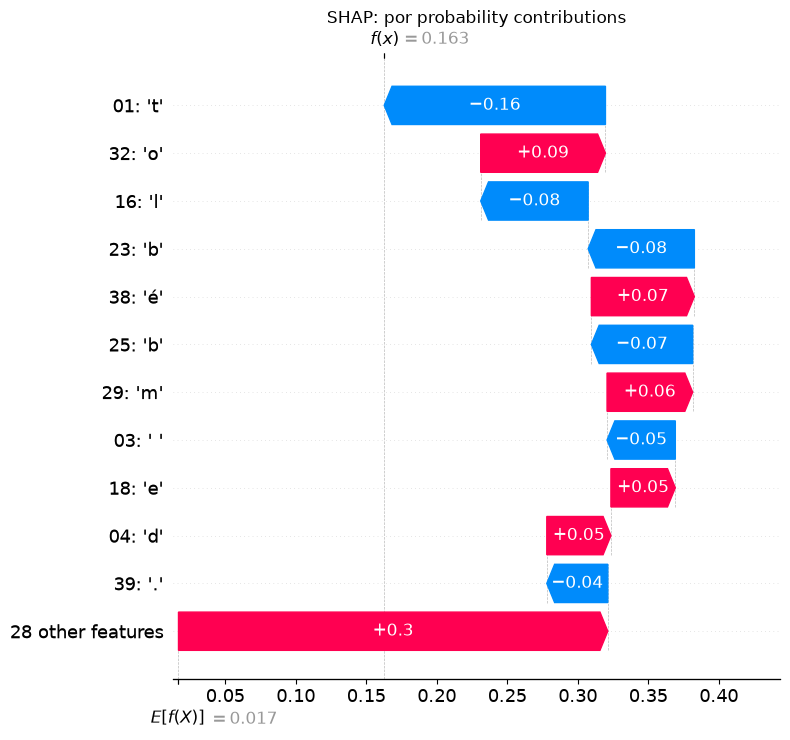

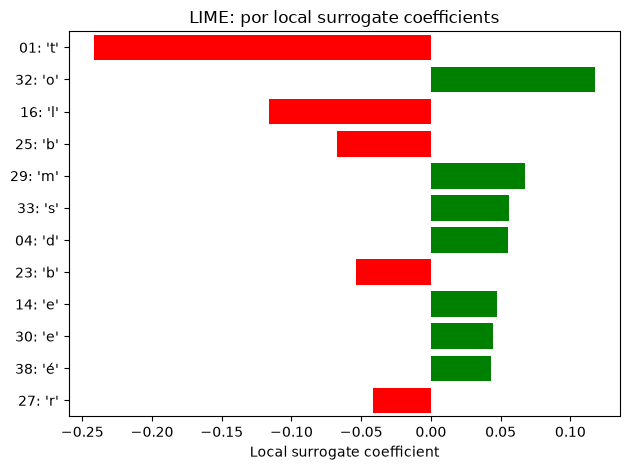

,language,model_probability,SHAP_baseline,SHAP_reconstructed,LIME_local_prediction,LIME_absolute_error,LIME_weighted_R2
0,epo,0.410581,0.062804,0.410581,0.371959,0.038621,0.624889
1,por,0.162683,0.016806,0.162683,0.233216,0.070533,0.547568


LIME inference batches: 1 for 2 explained classes.


In [8]:
def explain_language_text(text, true_language=None, shap_samples=512, lime_samples=2000):
    text = normalize_text(text)[:MAX_LENGTH]
    if not text:
        raise ValueError('Provide a non-empty sentence to explain.')
    if true_language is not None and true_language not in languages:
        raise ValueError('true_language must be one of the supported language codes.')
    probabilities = predict_proba(text)[0]
    predicted_index = int(probabilities.argmax())
    targets = list(dict.fromkeys([predicted_index] +
                   ([languages.index(true_language)] if true_language is not None else [])))
    feature_names = [f'{position + 1:02d}: {character!r}' for position, character in enumerate(text)]
    mask_probability = getattr(model, 'character_mask_probability', 0.0)
    if mask_probability == 0:
        print('CAUTION: this legacy model did not train its UNK embedding. Retrain with character masking.')
    mask_probabilities = make_mask_predictor(text)
    prediction_cache = {}

    def cached_probabilities(texts):
        key = tuple(texts)
        if key not in prediction_cache:
            prediction_cache[key] = predict_proba(texts)
        return prediction_cache[key]

    empty_mask, full_mask = np.zeros((1, len(text))), np.ones((1, len(text)))
    assert np.allclose(mask_probabilities(full_mask)[0], probabilities, atol=1e-6)
    kernel_explainer = shap.KernelExplainer(mask_probabilities, empty_mask, link='identity')
    previous_random_state = np.random.get_state()
    np.random.seed(SEED)
    try:
        shap_values = np.asarray(kernel_explainer.shap_values(
            full_mask, nsamples=shap_samples, l1_reg=0, silent=True,
        ))
    finally:
        np.random.set_state(previous_random_state)
    base_values = np.asarray(kernel_explainer.expected_value)
    reconstructed = base_values + shap_values[0].sum(axis=0)
    assert shap_values.shape == (1, len(text), len(languages)) and np.isfinite(shap_values).all()
    assert np.allclose(reconstructed, probabilities, atol=1e-5)

    print(f'Text: {text}\nPredicted: {languages[predicted_index]} ({probabilities[predicted_index]:.2%}); '
          f'actual: {true_language or "not supplied"}')
    reports, attribution_tables, lime_explanations = [], {}, {}
    for target in targets:
        code = languages[target]
        lime_explainer = LimeTextExplainer(
            class_names=languages, char_level=True, bow=False, mask_string=MASK_CHARACTER,
            random_state=SEED, feature_selection='none',
        )
        explanation = lime_explainer.explain_instance(
            text, cached_probabilities, labels=(target,), num_features=len(text), num_samples=lime_samples,
        )
        lime_weights = np.zeros(len(text))
        indexed_text = explanation.domain_mapper.indexed_string
        for feature_id, weight in explanation.as_map()[target]:
            lime_weights[int(indexed_text.string_position(feature_id)[0])] = weight
        local_prediction = float(np.asarray(explanation.local_pred).reshape(-1)[0])
        assert np.isfinite(lime_weights).all()
        reports.append(dict(
            language=code, model_probability=float(probabilities[target]),
            SHAP_baseline=float(base_values[target]), SHAP_reconstructed=float(reconstructed[target]),
            LIME_local_prediction=local_prediction,
            LIME_absolute_error=abs(local_prediction - float(probabilities[target])),
            LIME_weighted_R2=float(explanation.score),
        ))
        table = pd.DataFrame(dict(position=np.arange(1, len(text) + 1), character=list(text),
                                  SHAP=shap_values[0, :, target], LIME=lime_weights))
        attribution_tables[code], lime_explanations[code] = table, explanation
        print(f'\n{code}: positive contributions support this class; negative oppose it.')
        display(table.loc[table.SHAP.abs().nlargest(min(12, len(text))).index])
        shap.plots.waterfall(shap.Explanation(
            values=shap_values[0, :, target], base_values=base_values[target], feature_names=feature_names,
        ), max_display=12, show=False)
        plt.title(f'SHAP: {code} probability contributions')
        plt.tight_layout()
        plt.show()
        figure = explanation.as_pyplot_figure(label=target)
        axis = figure.axes[0]
        axis.set_yticklabels([feature_names[feature_id] for feature_id, _ in explanation.as_map()[target]][::-1])
        axis.set_ylim(max(0, len(text) - 12), len(text))
        axis.set(title=f'LIME: {code} local surrogate coefficients', xlabel='Local surrogate coefficient')
        figure.tight_layout()
        plt.show()

    report_frame = pd.DataFrame(reports)
    display(report_frame)
    print(f'LIME inference batches: {len(prediction_cache)} for {len(targets)} explained classes.')
    return dict(text=text, probabilities=probabilities, fidelity=report_frame,
                attributions=attribution_tables, lime_explanations=lime_explanations,
                lime_inference_batches=len(prediction_cache), character_mask_probability=mask_probability)


explanation_results = {'French example': explain_language_text(
    'Bonjour, je voudrais un billet pour Paris.', true_language='fra',
 )}
if not errors.empty:
    example = errors.iloc[0]
    explanation_results['Validation error'] = explain_language_text(
        example['text'], true_language=example['language'],
    )

In [9]:
from tempfile import TemporaryDirectory

for function in (encode_text, predict_language, explain_language_text):
    expect_value_error(function, '   ')
expect_value_error(explain_language_text, 'Hello!', true_language='unsupported')
expect_value_error(predict_language, 'Hello!', top_k=0)
expect_value_error(predict_language, 'Hello!', top_k=True)
expect_value_error(train_model, epochs=0)
expect_value_error(train_model, mask_probability=1.1)
expect_value_error(mask_training_characters, torch.tensor([[2, PAD_ID]]), -0.1)
assert encode_text(chr(0x1F642)).tolist() == [UNK_ID]
assert predict_proba([]).shape == (0, len(languages))
probe_ids, probe_lengths, _ = collate_sentences([(encode_text('Hello world!'), 0)])
padded_ids = nn.functional.pad(probe_ids, (0, 9), value=PAD_ID)
assert np.allclose(batch_probabilities(probe_ids, probe_lengths),
                   batch_probabilities(padded_ids, probe_lengths), atol=1e-6)
probabilities = predict_proba(list(example_sentences.values()))
assert np.isfinite(probabilities).all() and np.allclose(probabilities.sum(axis=1), 1, atol=1e-6)
assert np.allclose(probabilities, np.vstack([predict_proba(text) for text in example_sentences.values()]), atol=1e-6)

for result in explanation_results.values():
    assert result['lime_inference_batches'] == 1
    for explanation in result['lime_explanations'].values():
        indexed = explanation.domain_mapper.indexed_string
        assert indexed.inverse_removing(np.arange(indexed.num_words())) == MASK_CHARACTER * len(result['text'])
fidelity = pd.concat([result['fidelity'].assign(example=name)
                      for name, result in explanation_results.items()], ignore_index=True)
display(fidelity.assign(weak_fit=(fidelity.LIME_weighted_R2 < 0.7) | (fidelity.LIME_absolute_error > 0.05)))
print('weak_fit=True: interpret these LIME weights cautiously.')

print('CPU smoke check: two fresh one-epoch runs on 32 examples; the live model is not replaced.')
tiny_train, tiny_val = [DataLoader(dataset[:32], **loader_options) for dataset in (train_dataset, val_dataset)]
torch.manual_seed(SEED)
initial_unk = LanguageRNN(**model_config).embedding.weight[UNK_ID].detach().clone()
first_model, first_history, _, first_loss = train_model(
    1, train_batches=tiny_train, val_batches=tiny_val, training_device='cpu')
second_model, second_history, _, _ = train_model(
    1, train_batches=tiny_train, val_batches=tiny_val, training_device='cpu')
assert first_history.equals(second_history)
assert all(torch.equal(value, second_model.state_dict()[name]) for name, value in first_model.state_dict().items())
assert not torch.equal(first_model.embedding.weight[UNK_ID].detach(), initial_unk)
assert np.isclose(run_epoch(first_model, tiny_val)[0], first_loss, atol=1e-6)
first_model.character_mask_probability = 0
assert np.isclose(run_epoch(first_model, tiny_val)[0], first_loss, atol=1e-6)
first_model.character_mask_probability = 0.1
expect_value_error(run_epoch, first_model, [])

with TemporaryDirectory() as directory:
    temporary_path = Path(directory) / 'roundtrip.pt'
    save_language_model(temporary_path)
    restored_model, restored_checkpoint = load_language_model(temporary_path)
    assert np.allclose(probabilities, predict_proba(list(example_sentences.values()), predictor=restored_model), atol=1e-6)
    assert restored_model.character_mask_probability == getattr(model, 'character_mask_probability', 0.0)
    assert predict_language('Hello world!', predictor=restored_model).code.tolist() == predict_language('Hello world!').code.tolist()
    assert all(torch.equal(value.detach().cpu(), restored_checkpoint['model_state_dict'][name])
               for name, value in model.state_dict().items())
    try:
        save_language_model(temporary_path)
    except FileExistsError:
        pass
    else:
        raise AssertionError('Saving must refuse to overwrite an existing file by default.')

benchmark_masks = np.random.RandomState(SEED).randint(0, 2, (512, len(mask_text)))

def text_mask_probabilities(masks):
    return predict_proba([''.join(character if keep else MASK_CHARACTER
                                 for character, keep in zip(mask_text, mask)) for mask in masks])

assert np.allclose(mask_predictor(benchmark_masks), text_mask_probabilities(benchmark_masks), atol=1e-6)
timings = {'text': [], 'tensor': []}
for repeat in range(3):
    for name, function in [('text', text_mask_probabilities), ('tensor', mask_predictor)]:
        start = time.perf_counter()
        function(benchmark_masks)
        timings[name].append(time.perf_counter() - start)
text_time, tensor_time = np.median(timings['text']), np.median(timings['tensor'])
print(f'512 masks, median of 3 runs: text {text_time:.3f}s, tensor {tensor_time:.3f}s; ratio {text_time / tensor_time:.2f}x.')
print('Passed: input guards, padding, SHAP parity/additivity, LIME caching, CPU reproducibility, learned UNK, and checkpoint round-trip.')

,language,model_probability,SHAP_baseline,SHAP_reconstructed,LIME_local_prediction,LIME_absolute_error,LIME_weighted_R2,example,weak_fit
0,fra,0.998456,0.003925,0.998456,1.177459,0.179003,0.629077,French example,True
1,epo,0.410581,0.062804,0.410581,0.371959,0.038621,0.624889,Validation error,True
2,por,0.162683,0.016806,0.162683,0.233216,0.070533,0.547568,Validation error,True


weak_fit=True: interpret these LIME weights cautiously.
CPU smoke check: two fresh one-epoch runs on 32 examples; the live model is not replaced.
Epoch 01: train 2.3304/3.12% | validation 2.4314/0.00% | 0.2s
Restored best model from epoch 1.
Epoch 01: train 2.3304/3.12% | validation 2.4314/0.00% | 0.2s
Restored best model from epoch 1.
Saved checkpoint: C:\Users\nizare\AppData\Local\Temp\tmpw990pbzy\roundtrip.pt
512 masks, median of 3 runs: text 0.108s, tensor 0.085s; ratio 1.28x.
Passed: input guards, padding, SHAP parity/additivity, LIME caching, CPU reproducibility, learned UNK, and checkpoint round-trip.


## Interpretation Findings from the Final Masked GRU

These observations come from the freshly trained, epoch-10 GRU with character masking probability 0.1. Character positions are one-based positions in normalized, truncated input.

- **Correct French prediction:** `bonjour, je voudrais un billet pour paris.` receives **99.85%** French probability. The all-UNK baseline is about 0.0039, and SHAP contributions reconstruct 0.9985. The space at position 36 contributes about +0.1100 and the `o` at position 33 contributes +0.1006. Both methods support the `u` characters at positions 6, 15, and 34, while the `b` at position 25 opposes French. Spaces matter as position-dependent boundary/context features; this does not imply that a space intrinsically identifies French.
- **Portuguese mistaken for Esperanto:** the first validation error, `tu deverias realmente beber menos cafe.` (with an acute accent on the final `e` in the actual input), receives **41.06% Esperanto** and **16.27% Portuguese** probability. Both methods assign the accented `e` at position 38 a large negative Esperanto contribution (SHAP about -0.3213, LIME -0.3299), and a positive Portuguese contribution (SHAP +0.0731, LIME +0.0429). The space at position 3 supports Esperanto and opposes Portuguese. Opposing contributions coexist; the accent alone does not determine the final class. These are observations about the model, not correct linguistic rules.

### LIME Fidelity

| Example / Explained Class | RNN Probability | LIME Fitted Value | Absolute Error | Weighted R-squared |
|---|---|---|---|---|
| French example / French | 0.9985 | 1.1775 | 0.1790 | 0.6291 |
| Validation error / Esperanto | 0.4106 | 0.3720 | 0.0386 | 0.6249 |
| Validation error / Portuguese | 0.1627 | 0.2332 | 0.0705 | 0.5476 |

All three fits trigger the diagnostic heuristic (R-squared below 0.7 or absolute error above 0.05). The French surrogate overshoots 1 because it is an unconstrained local regression, not a calibrated probability model. Esperanto's relatively small fitted-value error does not remove its moderate neighborhood fit. LIME rankings should therefore be treated as approximate and checked against SHAP and additional examples, not as a faithful decomposition.

### Verification and Limitations

The notebook checks finite normalized probabilities, batch/single agreement, padding invariance, SHAP mask equivalence and additivity, consistent LIME masking, and shared cached perturbation inference across explained classes. Two tiny CPU training runs test reproducibility and a learned UNK embedding without replacing the final model. Temporary checkpoint tests verify saving/loading and overwrite protection. The mask benchmark measures the text and tensor routes locally; it is not an end-to-end performance guarantee.

Masked training gives UNK an embedding learned from partially masked sentences, but a completely masked sentence is still artificial and not a neutral or population-average baseline. SHAP values depend on this background and are sampled estimates; additivity proves reconstruction, not stable or causal character effects. LIME and SHAP operate locally and can disagree because recurrent interactions are nonlinear. Here the French largest positive SHAP feature (space at position 36) is not LIME's largest feature (`u` at position 6). Multiple seeds, baseline choices, and masking patterns would be needed for a stability study.

The linear n-gram baseline's **99.26%** accuracy exceeds the GRU's **96.34%** on this validation split. The RNN satisfies the recurrent-model experiment but is not the best tested classifier. No independent test set, multi-seed performance estimate, exhaustive hyperparameter search, or controlled masking ablation was performed. GPU behavior was not tested. The older unmasked checkpoint remains separate and its former numeric findings are not used in this final report.